In [ ]:
# ==========================================
# Step 1.1: Import Required Libraries
# ==========================================

import os
import cv2
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
# ==========================================
# Step 1.2: Download Dataset from KaggleHub
# ==========================================

import kagglehub

dataset_path = kagglehub.dataset_download(
    "kmader/skin-cancer-mnist-ham10000"
)

print("Dataset downloaded successfully!")
print("Dataset Location:", dataset_path)

100%|██████████| 5.20G/5.20G [00:48<00:00, 116MB/s]

Extracting files...


Dataset downloaded successfully!
Dataset Location: /root/.cache/kagglehub/datasets/kmader/skin-cancer-mnist-ham10000/versions/2


In [ ]:
# ==========================================
# Step 1.3: Explore Dataset Directory
# ==========================================

print("\nFiles inside the dataset directory:\n")

for file in os.listdir(dataset_path):
    print(file)


Files inside the dataset directory:

hmnist_8_8_L.csv
HAM10000_images_part_1
ham10000_images_part_2
HAM10000_metadata.csv
HAM10000_images_part_2
hmnist_28_28_RGB.csv
hmnist_28_28_L.csv
ham10000_images_part_1
hmnist_8_8_RGB.csv


In [ ]:
# ==========================================
# Step 1.4: Load Metadata
# ==========================================

metadata = pd.read_csv(
    os.path.join(
        dataset_path,
        "HAM10000_metadata.csv"
    )
)

print("Metadata Loaded Successfully!")

Metadata Loaded Successfully!


In [ ]:
metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
metadata.tail()

,lesion_id,image_id,dx,dx_type,age,sex,localization
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face
10014,HAM_0003521,ISIC_0032258,mel,histo,70.0,female,back


In [ ]:
print(f"Number of Rows    : {metadata.shape[0]}")
print(f"Number of Columns : {metadata.shape[1]}")

Number of Rows    : 10015
Number of Columns : 7


In [ ]:
print(metadata.columns)

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='object')


In [ ]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


In [ ]:
metadata.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
lesion_id,10015,7470,HAM_0000835,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
image_id,10015,10015,ISIC_0032258,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dx,10015,7,nv,6705,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dx_type,10015,4,histo,5340,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,9958.0,NaN,NaN,NaN,51.863828,16.968614,0.0,40.0,50.0,65.0,85.0
sex,10015,3,male,5406,NaN,NaN,NaN,NaN,NaN,NaN,NaN
localization,10015,15,back,2192,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
missing_values = metadata.isnull().sum()

missing_values

,0
lesion_id,0
image_id,0
dx,0
dx_type,0
age,57
sex,0
localization,0


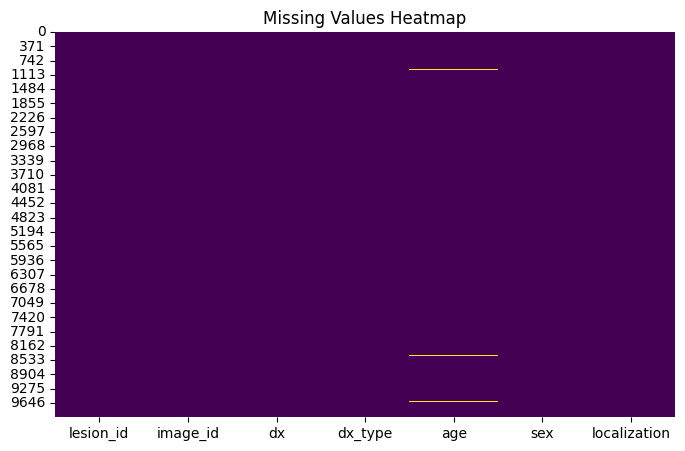

In [ ]:
plt.figure(figsize=(8,5))

sns.heatmap(
    metadata.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")

plt.show()

In [ ]:
print("Duplicate Rows:", metadata.duplicated().sum())

Duplicate Rows: 0


In [ ]:
metadata.sample(5, random_state=42)

,lesion_id,image_id,dx,dx_type,age,sex,localization
1617,HAM_0007180,ISIC_0033272,mel,histo,65.0,male,face
8128,HAM_0007195,ISIC_0031923,nv,histo,40.0,female,lower extremity
2168,HAM_0001835,ISIC_0026652,mel,histo,65.0,male,back
1090,HAM_0000465,ISIC_0030583,bkl,consensus,35.0,female,trunk
7754,HAM_0001720,ISIC_0034010,nv,histo,45.0,male,abdomen


In [ ]:
print("="*50)

print("Dataset Summary")

print("="*50)

print(f"Total Images       : {len(metadata)}")

print(f"Total Features     : {metadata.shape[1]}")

print(f"Missing Values     : {metadata.isnull().sum().sum()}")

print(f"Duplicate Records  : {metadata.duplicated().sum()}")

print("="*50)

Dataset Summary
Total Images       : 10015
Total Features     : 7
Missing Values     : 57
Duplicate Records  : 0


# **Exploratory Data Analysis (EDA)**

In [ ]:
# ==========================================
# Step 2.1: Basic Information
# ==========================================

print("="*60)
print("HAM10000 Dataset Overview")
print("="*60)

print(f"Number of Images      : {metadata.shape[0]}")
print(f"Number of Features    : {metadata.shape[1]}")

print("\nColumn Names:")
print(metadata.columns.tolist())

HAM10000 Dataset Overview
Number of Images      : 10015
Number of Features    : 7

Column Names:
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']


In [ ]:
# ==========================================
# Step 2.2: Data Types
# ==========================================

metadata.dtypes

,0
lesion_id,object
image_id,object
dx,object
dx_type,object
age,float64
sex,object
localization,object


In [ ]:
# ==========================================
# Step 2.3: Missing Values
# ==========================================

missing = metadata.isnull().sum()

missing

,0
lesion_id,0
image_id,0
dx,0
dx_type,0
age,57
sex,0
localization,0


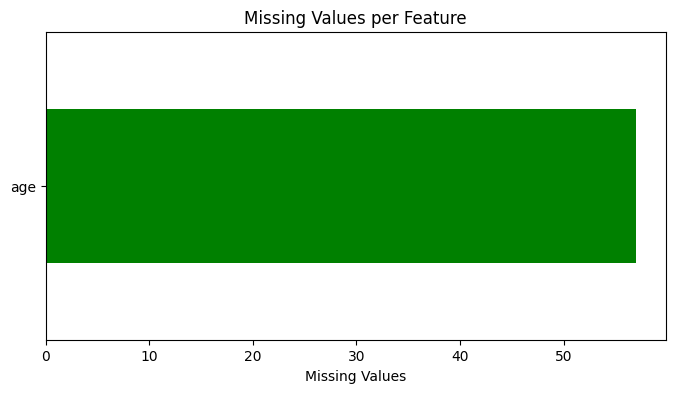

In [ ]:
missing = metadata.isnull().sum()

missing = missing[missing > 0]

plt.figure(figsize=(8,4))

missing.sort_values().plot(
    kind="barh",
    color="green"
)

plt.xlabel("Missing Values")

plt.title("Missing Values per Feature")

plt.show()

In [ ]:
metadata['dx']

,dx
0,bkl
1,bkl
2,bkl
3,bkl
4,bkl
...,...
10010,akiec
10011,akiec
10012,akiec
10013,akiec


In [ ]:
metadata['dx'].value_counts()

,count
dx,
nv,6705
mel,1113
bkl,1099
bcc,514
akiec,327
vasc,142
df,115


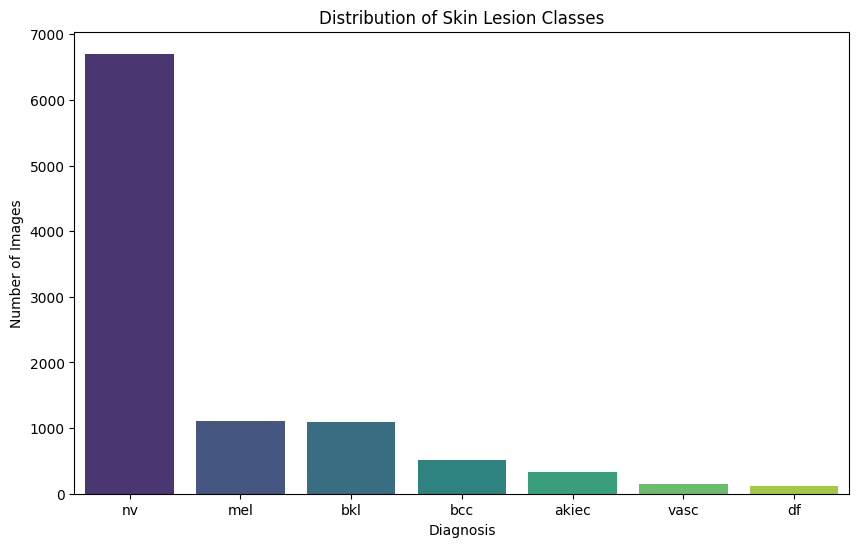

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='dx',
    data=metadata,
    palette="viridis",
    order=metadata['dx'].value_counts().index
)

plt.title("Distribution of Skin Lesion Classes")

plt.xlabel("Diagnosis")

plt.ylabel("Number of Images")

plt.show()

In [ ]:
class_percent = metadata['dx'].value_counts(normalize=True)*100

class_percent

,proportion
dx,
nv,66.949576
mel,11.113330
bkl,10.973540
bcc,5.132302
akiec,3.265102
vasc,1.417873
df,1.148278


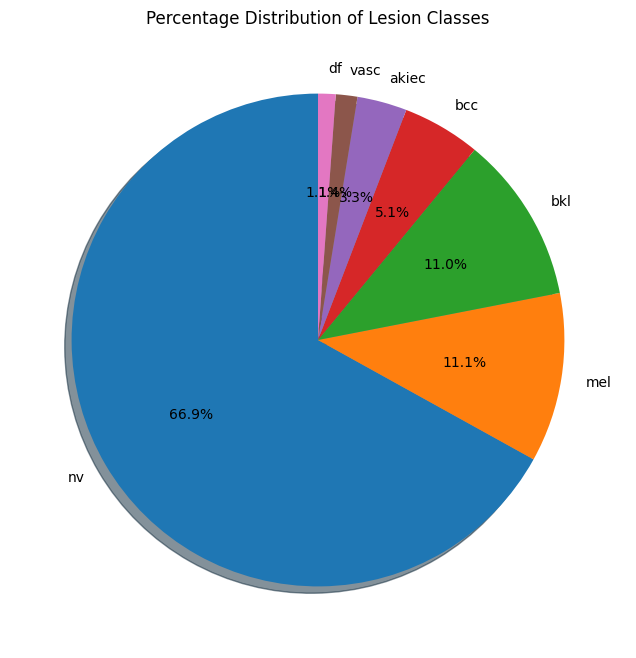

In [ ]:
plt.figure(figsize=(8,8))

plt.pie(
    class_percent,
    labels=class_percent.index,
    autopct="%1.1f%%",
    startangle=90,
    shadow=True
)

plt.title("Percentage Distribution of Lesion Classes")

plt.show()

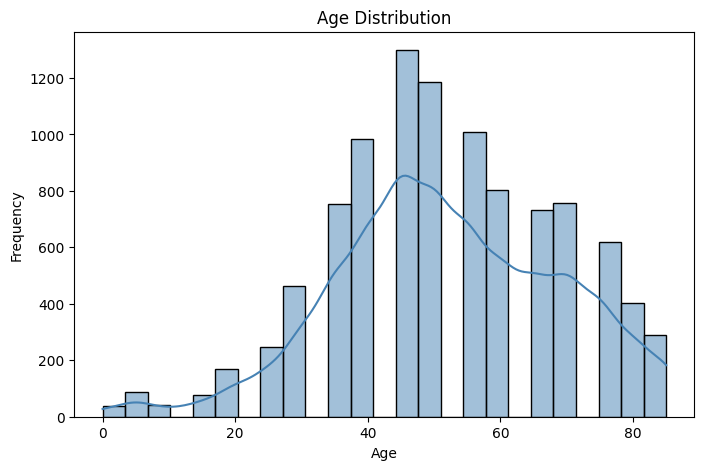

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    metadata['age'],
    bins=25,
    kde=True,
    color='steelblue'
)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

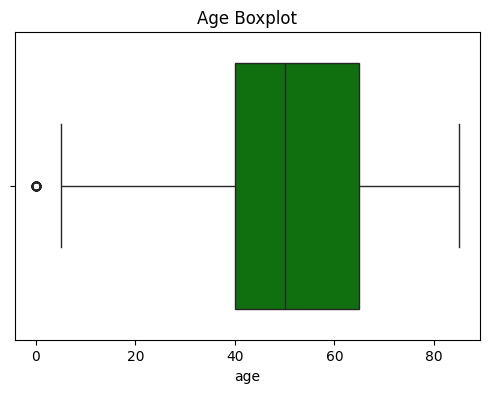

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x=metadata['age'],
    color='green'
)

plt.title("Age Boxplot")

plt.show()

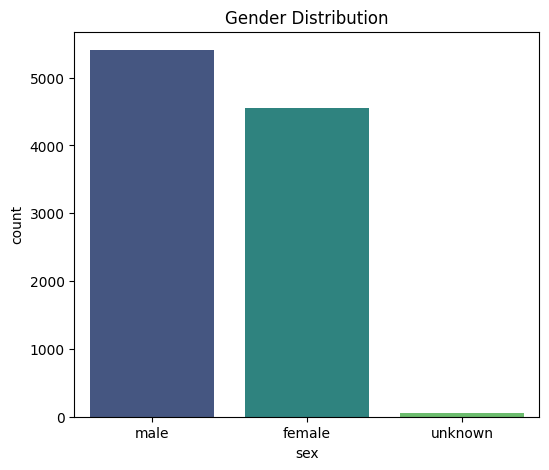

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='sex',
    data=metadata,
    palette="viridis"
)

plt.title("Gender Distribution")

plt.show()

In [ ]:
metadata['sex'].value_counts(normalize=True)*100

,proportion
sex,
male,53.979031
female,45.451822
unknown,0.569146


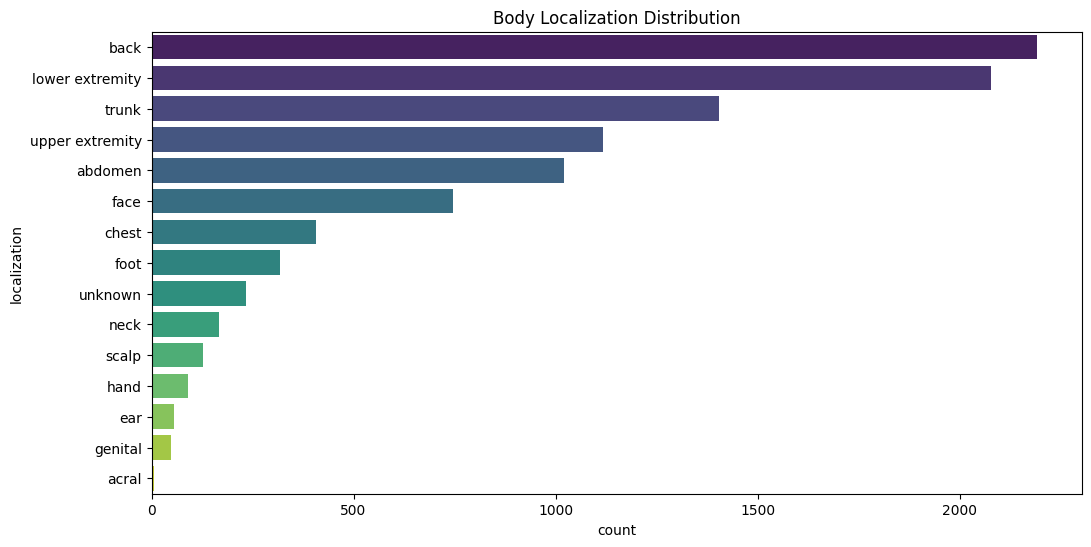

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='localization',
    data=metadata,
    order=metadata['localization'].value_counts().index,
    palette="viridis"
)

plt.title("Body Localization Distribution")

plt.show()

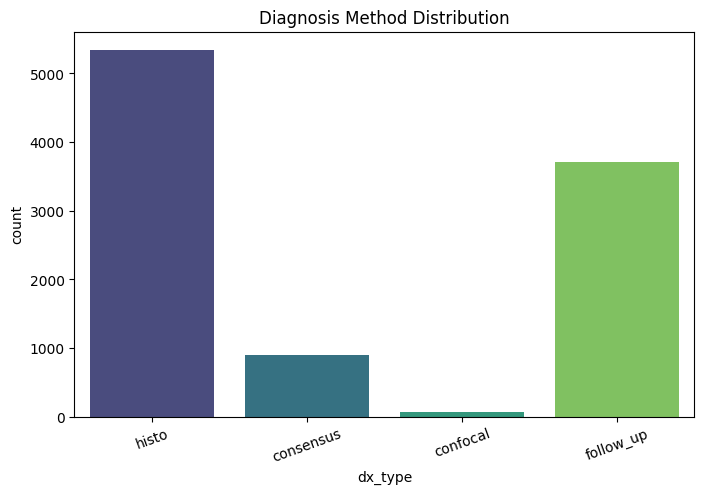

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='dx_type',
    data=metadata,
    palette="viridis"
)

plt.title("Diagnosis Method Distribution")

plt.xticks(rotation=20)

plt.show()

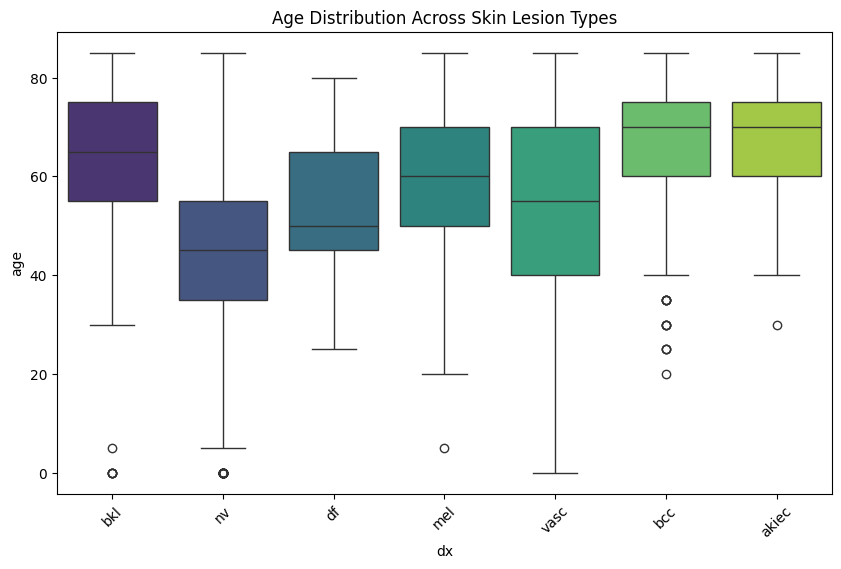

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='dx',
    y='age',
    data=metadata,
    palette="viridis"
)

plt.xticks(rotation=45)

plt.title("Age Distribution Across Skin Lesion Types")

plt.show()

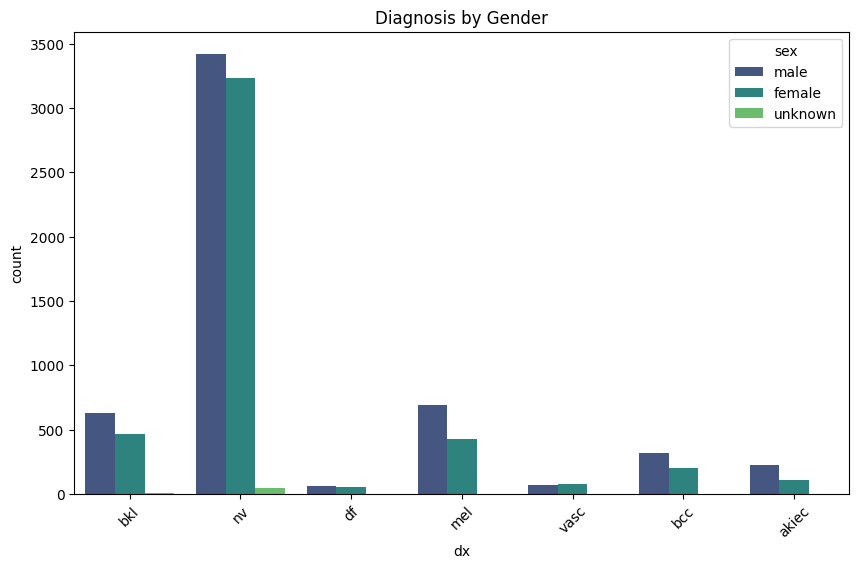

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='dx',
    hue='sex',
    data=metadata,
    palette="viridis"
)

plt.xticks(rotation=45)

plt.title("Diagnosis by Gender")

plt.show()

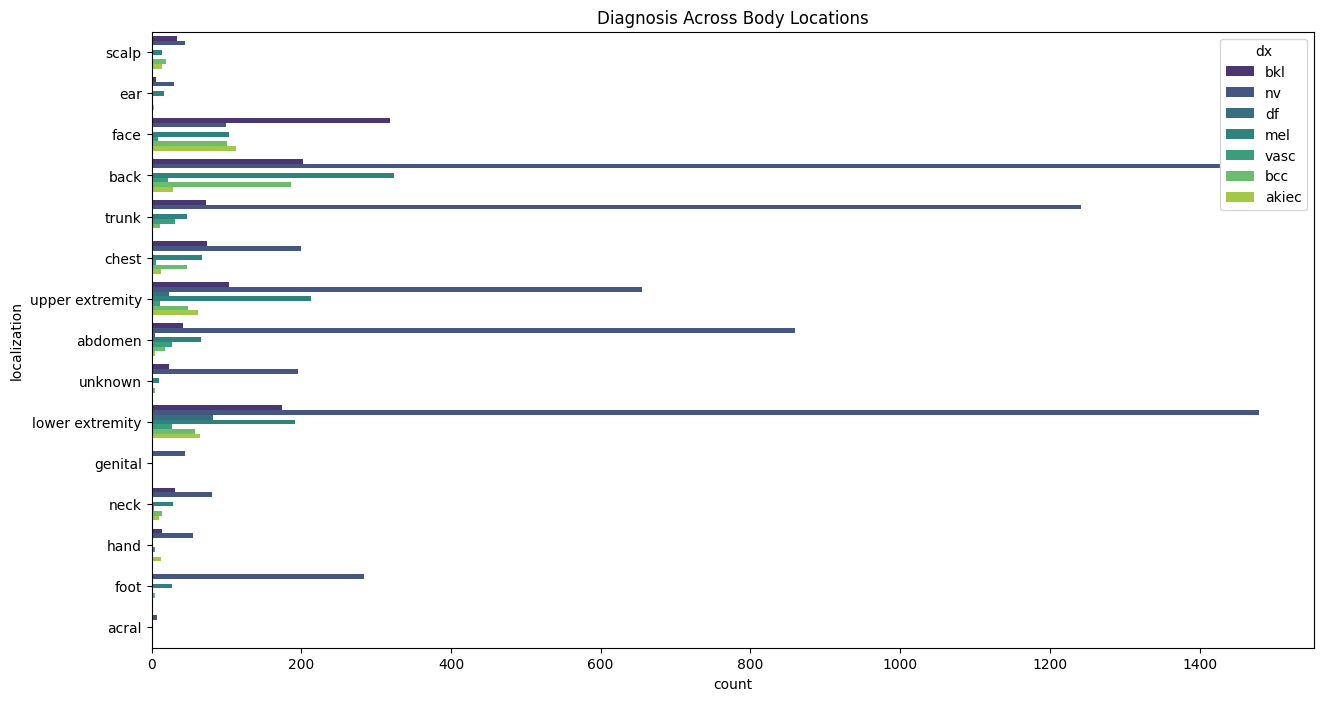

In [ ]:
plt.figure(figsize=(15,8))

sns.countplot(
    y='localization',
    hue='dx',
    data=metadata,
    palette="viridis"
)

plt.title("Diagnosis Across Body Locations")

plt.show()

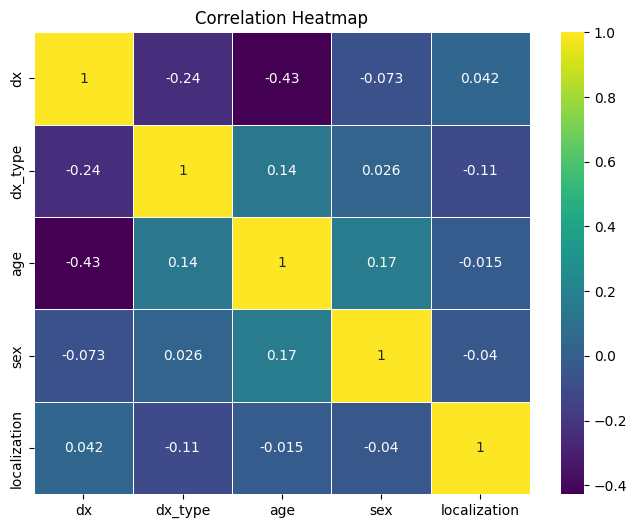

In [ ]:
eda_df = metadata.copy()

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in ['dx','dx_type','sex','localization']:
    eda_df[col] = encoder.fit_transform(eda_df[col].astype(str))

plt.figure(figsize=(8,6))

sns.heatmap(
    eda_df.corr(numeric_only=True),
    annot=True,
    cmap='viridis',
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
image_dir1 = os.path.join(dataset_path, "HAM10000_images_part_1")
image_dir2 = os.path.join(dataset_path, "HAM10000_images_part_2")

In [ ]:
image_paths = {}

for folder in [image_dir1, image_dir2]:
    for image in os.listdir(folder):
        image_paths[image.split(".")[0]] = os.path.join(folder, image)

In [ ]:
metadata["image_path"] = metadata["image_id"].map(image_paths)

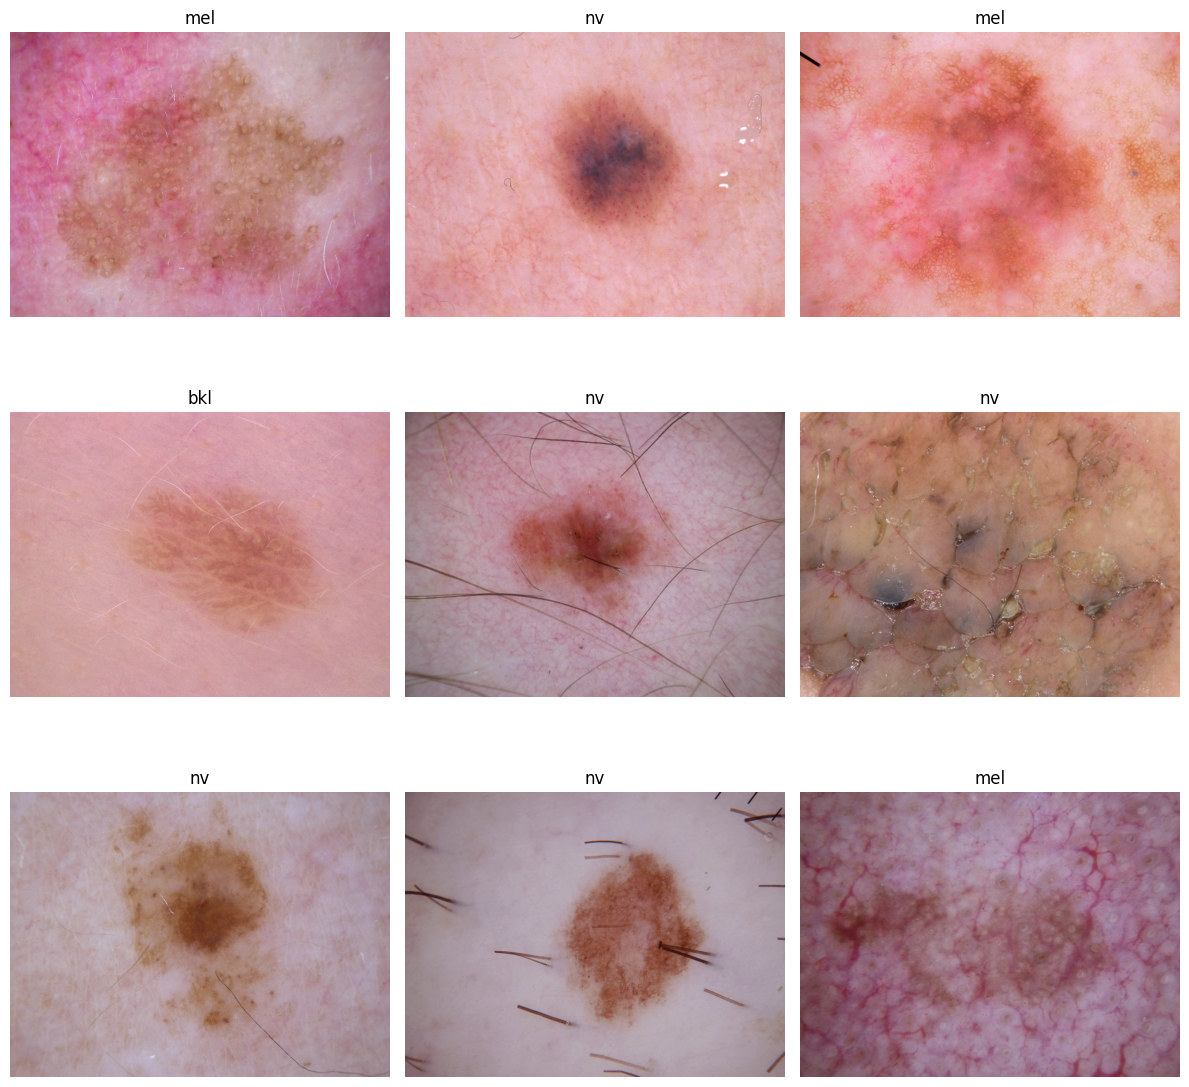

In [ ]:
plt.figure(figsize=(12,12))

sample = metadata.sample(9, random_state=42)

for i, (_, row) in enumerate(sample.iterrows()):

    plt.subplot(3,3,i+1)

    image = Image.open(row["image_path"])

    plt.imshow(image)

    plt.title(row["dx"])

    plt.axis("off")

plt.tight_layout()

plt.show()

# **Data Cleaning and Preprocessing**

In [ ]:
# Check missing values
print(metadata.isnull().sum())

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
image_path       0
dtype: int64


In [ ]:
metadata["age"] = metadata["age"].fillna(metadata["age"].median())

In [ ]:
for col in ["sex", "dx_type", "localization"]:
    metadata[col] = metadata[col].fillna(metadata[col].mode()[0])

In [ ]:
metadata.isnull().sum()

,0
lesion_id,0
image_id,0
dx,0
dx_type,0
age,0
sex,0
localization,0
image_path,0


In [ ]:
print("Duplicates:", metadata.duplicated().sum())

metadata = metadata.drop_duplicates()

Duplicates: 0


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

metadata["label"] = label_encoder.fit_transform(metadata["dx"])

In [ ]:
mapping = dict(zip(label_encoder.classes_,
                   label_encoder.transform(label_encoder.classes_)))

print(mapping)

{'akiec': np.int64(0), 'bcc': np.int64(1), 'bkl': np.int64(2), 'df': np.int64(3), 'mel': np.int64(4), 'nv': np.int64(5), 'vasc': np.int64(6)}


In [ ]:
image_dir1 = os.path.join(dataset_path,"HAM10000_images_part_1")
image_dir2 = os.path.join(dataset_path,"HAM10000_images_part_2")

In [ ]:
image_paths = {}

for folder in [image_dir1,image_dir2]:

    for image in os.listdir(folder):

        image_id = image.split(".")[0]

        image_paths[image_id] = os.path.join(folder,image)

In [ ]:
metadata["image_path"] = metadata["image_id"].map(image_paths)

In [ ]:
metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/root/.cache/kagglehub/datasets/kmader/skin-ca...,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/root/.cache/kagglehub/datasets/kmader/skin-ca...,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/root/.cache/kagglehub/datasets/kmader/skin-ca...,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/root/.cache/kagglehub/datasets/kmader/skin-ca...,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/root/.cache/kagglehub/datasets/kmader/skin-ca...,2


In [ ]:
print(metadata["image_path"].isnull().sum())

0


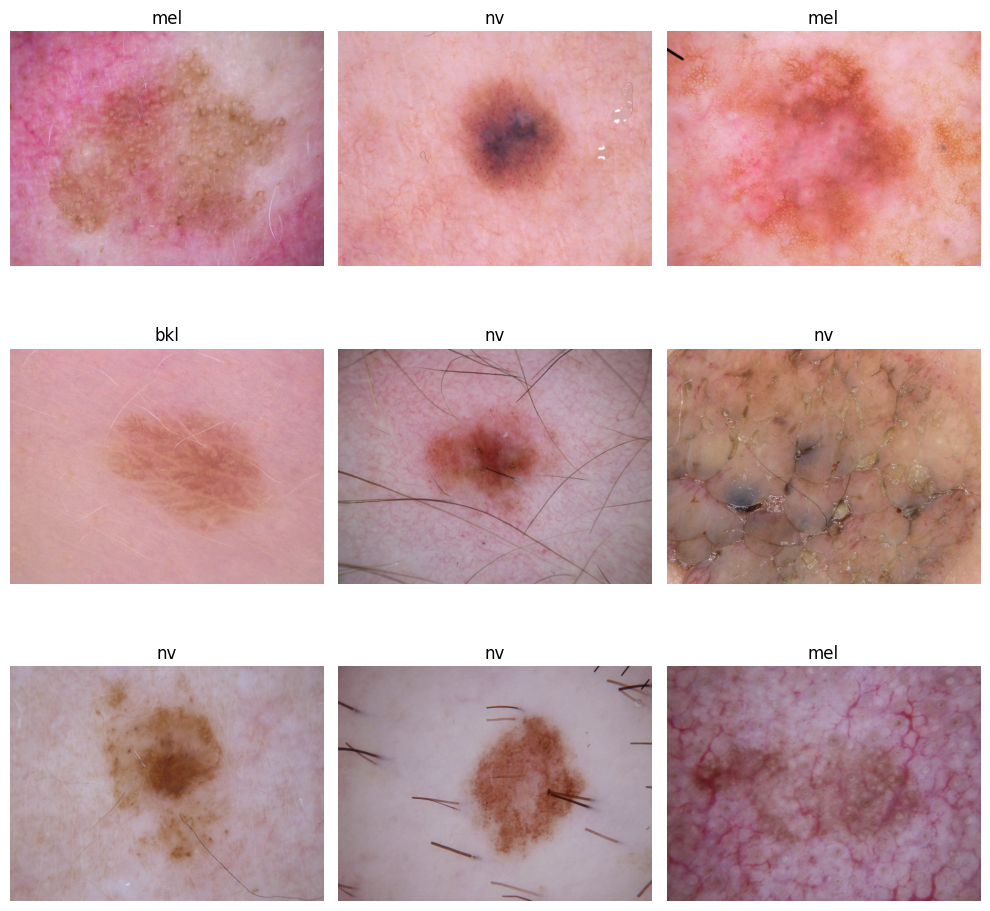

In [ ]:
plt.figure(figsize=(10,10))

sample = metadata.sample(9, random_state=42)

for i,(_,row) in enumerate(sample.iterrows()):

    img = cv2.imread(row["image_path"])

    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(row["dx"])

    plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [ ]:
cnn = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
features = []

labels = []

BATCH_SIZE = 32

In [ ]:
for start in range(0,len(metadata),BATCH_SIZE):

    batch = metadata.iloc[start:start+BATCH_SIZE]

    batch_images = []

    for _,row in batch.iterrows():

        img = cv2.imread(row["image_path"])

        img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

        img = cv2.resize(
            img,
            (224,224),
            interpolation=cv2.INTER_AREA
        )

        batch_images.append(img)

    batch_images = np.array(batch_images,dtype=np.float32)

    batch_images = preprocess_input(batch_images)

    batch_features = cnn.predict(
        batch_images,
        verbose=0
    )

    features.append(batch_features)

    labels.extend(batch["label"].values)

    if start % 320 == 0:

        print(f"Processed {start}/{len(metadata)} images")

Processed 0/10015 images
Processed 320/10015 images
Processed 640/10015 images
Processed 960/10015 images
Processed 1280/10015 images
Processed 1600/10015 images
Processed 1920/10015 images
Processed 2240/10015 images
Processed 2560/10015 images
Processed 2880/10015 images
Processed 3200/10015 images
Processed 3520/10015 images
Processed 3840/10015 images
Processed 4160/10015 images
Processed 4480/10015 images
Processed 4800/10015 images
Processed 5120/10015 images
Processed 5440/10015 images
Processed 5760/10015 images
Processed 6080/10015 images
Processed 6400/10015 images
Processed 6720/10015 images
Processed 7040/10015 images
Processed 7360/10015 images
Processed 7680/10015 images
Processed 8000/10015 images
Processed 8320/10015 images
Processed 8640/10015 images
Processed 8960/10015 images
Processed 9280/10015 images
Processed 9600/10015 images
Processed 9920/10015 images


In [ ]:
features = np.vstack(features)

labels = np.array(labels)

In [ ]:
print(features.shape)

print(labels.shape)

(10015, 1280)
(10015,)


In [ ]:
np.save("mobilenet_features.npy",features)

np.save("labels.npy",labels)

In [ ]:
features = np.load("mobilenet_features.npy")

labels = np.load("labels.npy")

# **Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# ==========================================
# Step 4: Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

In [ ]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print()

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Features : (8012, 1280)
Testing Features  : (2003, 1280)

Training Labels : (8012,)
Testing Labels  : (2003,)


In [ ]:
print(pd.Series(y_train).value_counts())

print()

print(pd.Series(y_test).value_counts())

5    5364
4     890
2     879
1     411
0     262
6     114
3      92
Name: count, dtype: int64

5    1341
4     223
2     220
1     103
0      65
6      28
3      23
Name: count, dtype: int64


# **Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)

In [ ]:
print(X_train_scaled.shape)
X_test_scaled = scaler.transform(X_test)
print(X_test_scaled.shape)

(8012, 1280)
(2003, 1280)


In [ ]:
print("Mean :", np.mean(X_train_scaled))

print("Std :", np.std(X_train_scaled))

Mean : -2.946011e-10
Std : 1.0000002


In [ ]:
from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.naive_bayes import GaussianNB

from sklearn.tree import DecisionTreeClassifier

In [ ]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=2000),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "SVM": SVC(kernel="rbf", probability=True),

    "Naive Bayes": GaussianNB(),

    "Decision Tree": DecisionTreeClassifier(random_state=42)

}

In [ ]:
trained_models = {}

for name, model in models.items():

    print("="*50)

    print("Training", name)

    model.fit(X_train_scaled, y_train)

    trained_models[name] = model

print("\nTraining Completed!")

Training Logistic Regression
Training KNN
Training SVM
Training Naive Bayes
Training Decision Tree

Training Completed!


In [ ]:
predictions = {}

for name, model in trained_models.items():

    predictions[name] = model.predict(X_test_scaled)

In [ ]:
predictions["SVM"][:10]

In [ ]:
from sklearn.metrics import accuracy_score

from sklearn.metrics import precision_score

from sklearn.metrics import recall_score

from sklearn.metrics import f1_score

In [ ]:
results = pd.DataFrame(
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

In [ ]:
for name in trained_models:

    y_pred = predictions[name]

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    results.loc[len(results)] = [

        name,

        accuracy,

        precision,

        recall,

        f1

    ]

In [ ]:
for name in trained_models:

    y_pred = predictions[name]

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    results.loc[len(results)] = [

        name,

        accuracy,

        precision,

        recall,

        f1

    ]

In [ ]:
results

In [ ]:
results = results.sort_values(
    by="Accuracy",
    ascending=False
)

results

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=results,

    x="Accuracy",

    y="Model",

    palette="viridis"

)

plt.title("Model Accuracy Comparison")

plt.xlim(0,1)

plt.show()

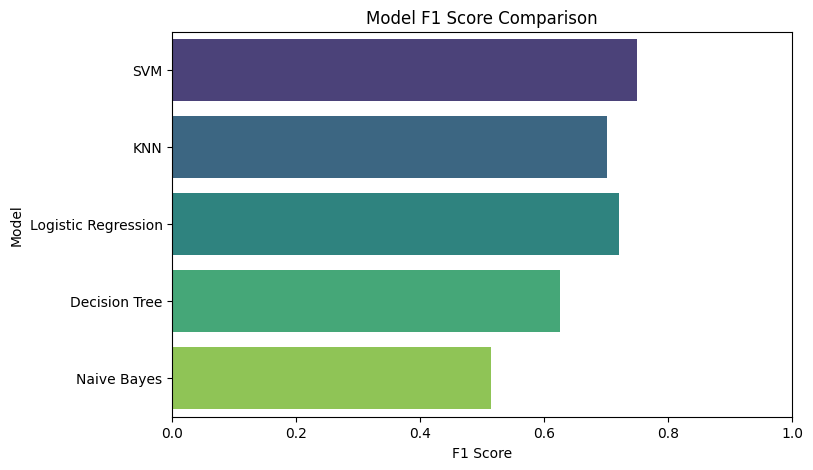

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=results,

    x="F1 Score",

    y="Model",

    palette="viridis"

)

plt.title("Model F1 Score Comparison")

plt.xlim(0,1)

plt.show()

In [ ]:
best_model_name = results.iloc[0]["Model"]

print("Best Model :", best_model_name)

Best Model : SVM


In [ ]:
from sklearn.metrics import confusion_matrix

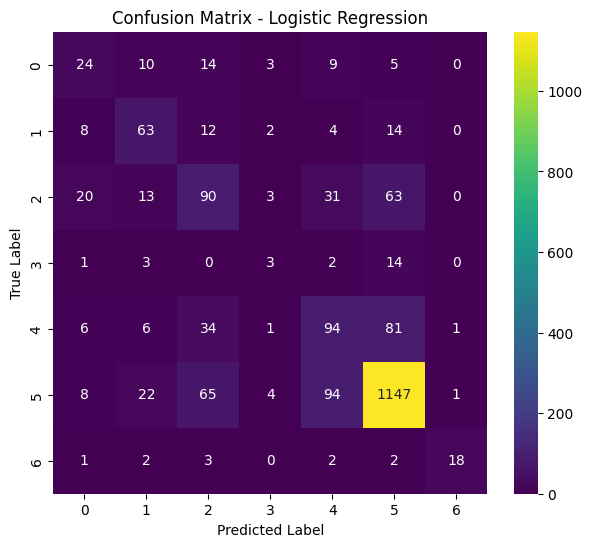

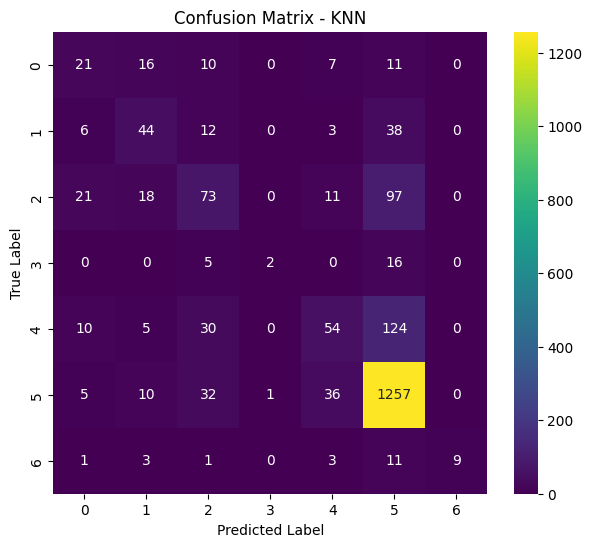

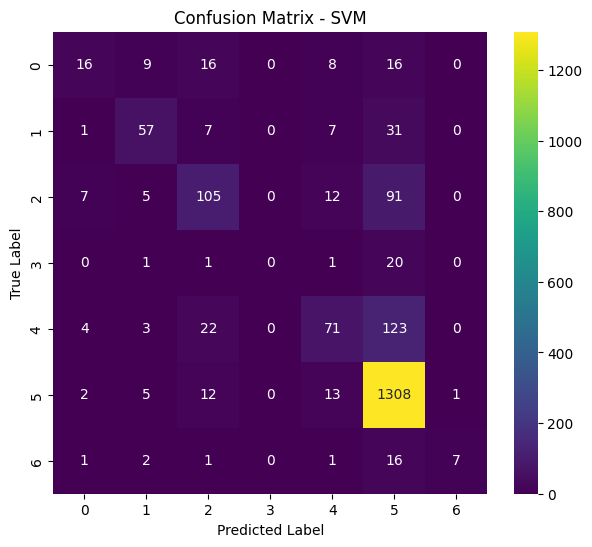

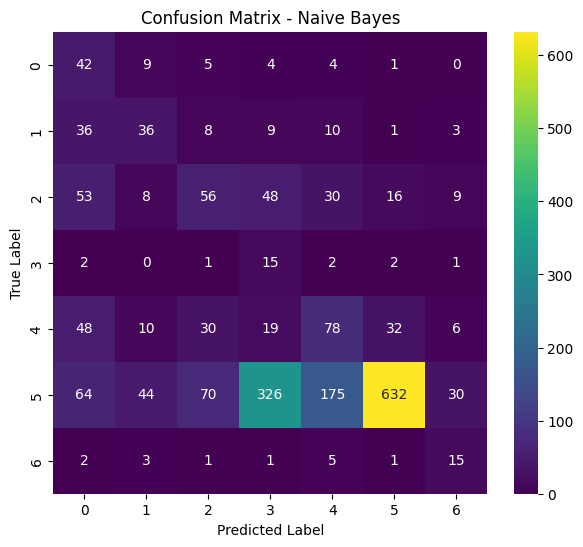

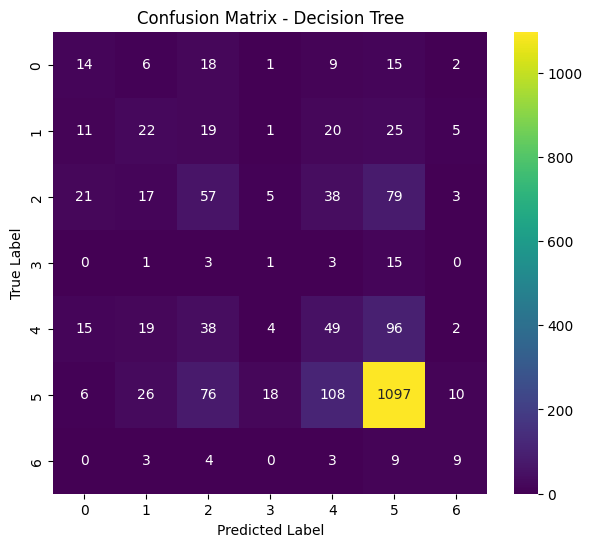

In [ ]:
# ==========================================
# Step 14: Confusion Matrix
# ==========================================

for name, model in trained_models.items():

    y_pred = model.predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(7,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='viridis'
    )

    plt.title(f"Confusion Matrix - {name}")

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.show()

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
# ==========================================
# Step 15: Classification Report
# ==========================================

for name, model in trained_models.items():

    print("="*70)

    print(f"Classification Report : {name}")

    print("="*70)

    y_pred = model.predict(X_test_scaled)

    print(classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    ))

    print("\n")

Classification Report : Logistic Regression
              precision    recall  f1-score   support

       akiec       0.35      0.37      0.36        65
         bcc       0.53      0.61      0.57       103
         bkl       0.41      0.41      0.41       220
          df       0.19      0.13      0.15        23
         mel       0.40      0.42      0.41       223
          nv       0.87      0.86      0.86      1341
        vasc       0.90      0.64      0.75        28

    accuracy                           0.72      2003
   macro avg       0.52      0.49      0.50      2003
weighted avg       0.72      0.72      0.72      2003



Classification Report : KNN
              precision    recall  f1-score   support

       akiec       0.33      0.32      0.33        65
         bcc       0.46      0.43      0.44       103
         bkl       0.45      0.33      0.38       220
          df       0.67      0.09      0.15        23
         mel       0.47      0.24      0.32       223
    

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

In [ ]:
y_test_bin = label_binarize(
    y_test,
    classes=np.unique(labels)
)

In [ ]:
best_model = trained_models[best_model_name]

y_score = best_model.predict_proba(X_test_scaled)

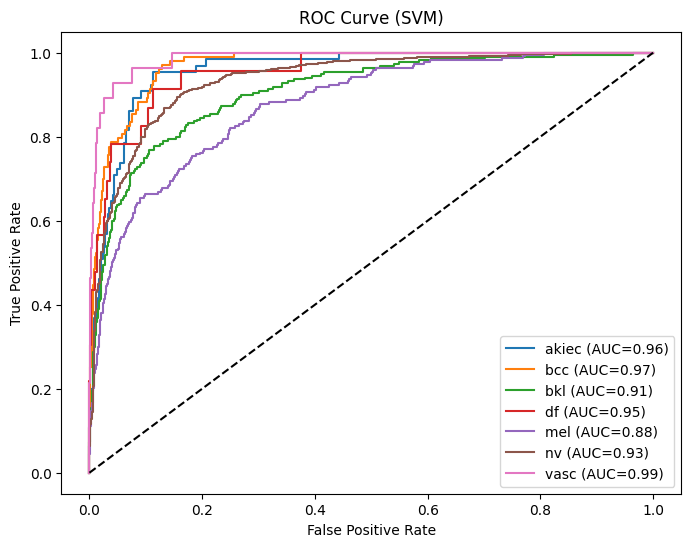

In [ ]:
plt.figure(figsize=(8,6))

for i in range(len(label_encoder.classes_)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:,i],
        y_score[:,i]
    )

    roc_auc = auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{label_encoder.classes_[i]} (AUC={roc_auc:.2f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title(f"ROC Curve ({best_model_name})")

plt.legend()

plt.show()

In [ ]:
results = results.round(4)

results

,Model,Accuracy,Precision,Recall,F1 Score
7,SVM,0.7808,0.7506,0.7808,0.7496
2,SVM,0.7808,0.7506,0.7808,0.7496
6,KNN,0.7289,0.6993,0.7289,0.7008
1,KNN,0.7289,0.6993,0.7289,0.7008
0,Logistic Regression,0.7184,0.7222,0.7184,0.7197
5,Logistic Regression,0.7184,0.7222,0.7184,0.7197
9,Decision Tree,0.6236,0.6258,0.6236,0.6246
4,Decision Tree,0.6236,0.6258,0.6236,0.6246
3,Naive Bayes,0.4363,0.7083,0.4363,0.5136
8,Naive Bayes,0.4363,0.7083,0.4363,0.5136


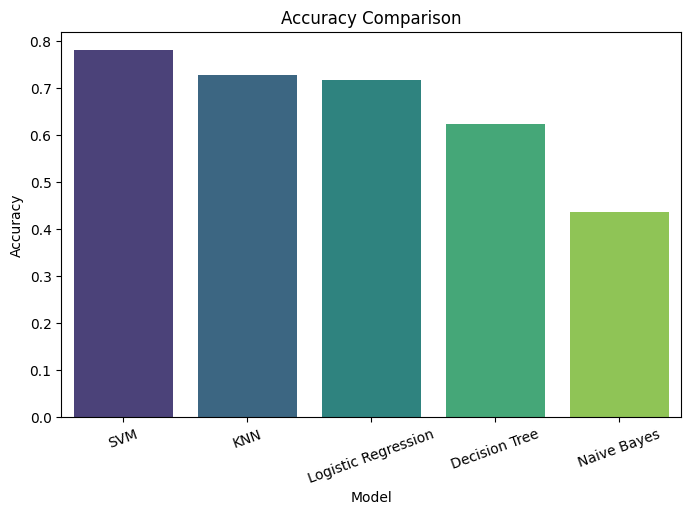

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.xticks(rotation=20)

plt.title("Accuracy Comparison")

plt.show()

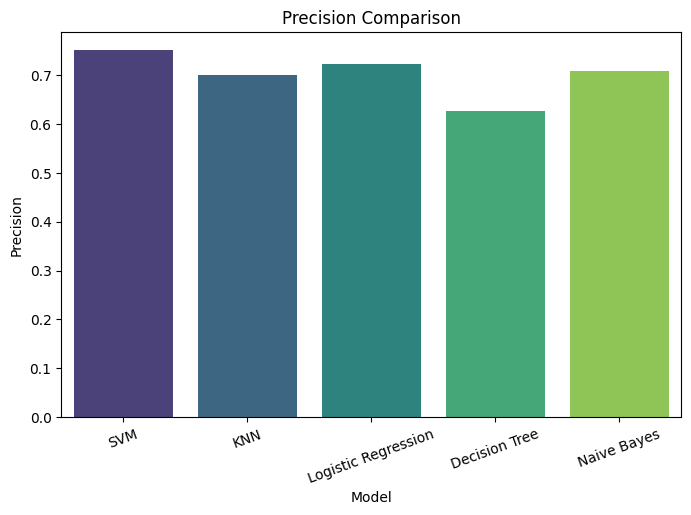

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Precision",
    palette="viridis"
)

plt.xticks(rotation=20)

plt.title("Precision Comparison")

plt.show()

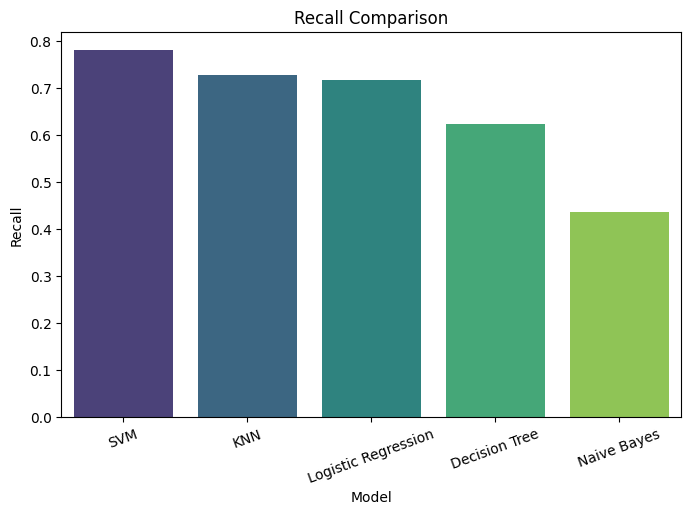

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Recall",
    palette="viridis"
)

plt.xticks(rotation=20)

plt.title("Recall Comparison")

plt.show()

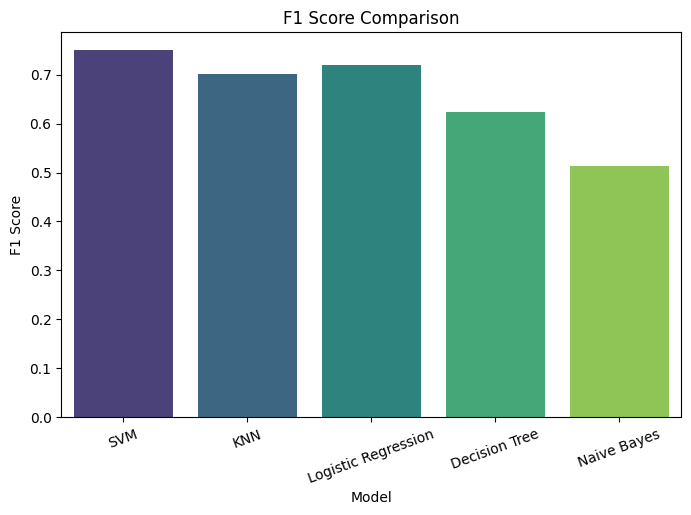

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="F1 Score",
    palette="viridis"
)

plt.xticks(rotation=20)

plt.title("F1 Score Comparison")

plt.show()

In [ ]:
print(results)

                 Model  Accuracy  Precision  Recall  F1 Score
7                  SVM    0.7808     0.7506  0.7808    0.7496
2                  SVM    0.7808     0.7506  0.7808    0.7496
6                  KNN    0.7289     0.6993  0.7289    0.7008
1                  KNN    0.7289     0.6993  0.7289    0.7008
0  Logistic Regression    0.7184     0.7222  0.7184    0.7197
5  Logistic Regression    0.7184     0.7222  0.7184    0.7197
9        Decision Tree    0.6236     0.6258  0.6236    0.6246
4        Decision Tree    0.6236     0.6258  0.6236    0.6246
3          Naive Bayes    0.4363     0.7083  0.4363    0.5136
8          Naive Bayes    0.4363     0.7083  0.4363    0.5136


In [ ]:
results.style.background_gradient(cmap="Greens")

,Model,Accuracy,Precision,Recall,F1 Score
7,SVM,0.780800,0.750600,0.780800,0.749600
2,SVM,0.780800,0.750600,0.780800,0.749600
6,KNN,0.728900,0.699300,0.728900,0.700800
1,KNN,0.728900,0.699300,0.728900,0.700800
0,Logistic Regression,0.718400,0.722200,0.718400,0.719700
5,Logistic Regression,0.718400,0.722200,0.718400,0.719700
9,Decision Tree,0.623600,0.625800,0.623600,0.624600
4,Decision Tree,0.623600,0.625800,0.623600,0.624600
3,Naive Bayes,0.436300,0.708300,0.436300,0.513600
8,Naive Bayes,0.436300,0.708300,0.436300,0.513600


In [ ]:
best_model_name = results.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print(best_model_name)

SVM


In [ ]:
import joblib

In [ ]:
joblib.dump(best_model, "skin_cancer_model.pkl")

['skin_cancer_model.pkl']

In [ ]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
joblib.dump(label_encoder, "label_encoder.pkl")

['label_encoder.pkl']

In [ ]:
cnn.save("mobilenet_feature_extractor.keras")

In [ ]:
import os

for file in os.listdir():
    print(file)

.config
mobilenet_feature_extractor.keras
scaler.pkl
label_encoder.pkl
labels.npy
skin_cancer_model.pkl
mobilenet_features.npy
sample_data


In [ ]:
model = joblib.load("skin_cancer_model.pkl")
scaler = joblib.load("scaler.pkl")
encoder = joblib.load("label_encoder.pkl")

In [ ]:
sample = X_test_scaled[:1]

prediction = model.predict(sample)

print(encoder.inverse_transform(prediction))

['nv']


In [ ]:
import os

print(os.getcwd())

/content


In [ ]:
import os

os.makedirs("models", exist_ok=True)

In [ ]:
os.listdir()

['.config',
 'mobilenet_feature_extractor.keras',
 'scaler.pkl',
 'label_encoder.pkl',
 'labels.npy',
 'models',
 'skin_cancer_model.pkl',
 'mobilenet_features.npy',
 'sample_data']

In [ ]:
import joblib

joblib.dump(best_model, "models/skin_cancer_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(label_encoder, "models/label_encoder.pkl")

cnn.save("models/mobilenet_feature_extractor.keras")

In [ ]:
os.listdir("models")

['mobilenet_feature_extractor.keras',
 'scaler.pkl',
 'label_encoder.pkl',
 'skin_cancer_model.pkl']

In [ ]:
print(dataset_path)

/root/.cache/kagglehub/datasets/kmader/skin-cancer-mnist-ham10000/versions/2


In [ ]:
import os

part1 = os.path.join(dataset_path, "HAM10000_images_part_1")
part2 = os.path.join(dataset_path, "HAM10000_images_part_2")

print(os.listdir(part1)[:10])

['ISIC_0024785.jpg', 'ISIC_0025927.jpg', 'ISIC_0026782.jpg', 'ISIC_0026379.jpg', 'ISIC_0027414.jpg', 'ISIC_0025858.jpg', 'ISIC_0028469.jpg', 'ISIC_0028098.jpg', 'ISIC_0026502.jpg', 'ISIC_0027813.jpg']


In [ ]:
import shutil

image_name = "ISIC_0024306.jpg"

shutil.copy(
    os.path.join(part1, image_name),
    "/content/sample.jpg"
)

'/content/sample.jpg'

In [ ]:
from google.colab import files

files.download("/content/sample.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil
from google.colab import files

shutil.make_archive("models", "zip", "models")

'/content/models.zip'

In [ ]:
files.download("models.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>